# Домашнее задание "Случайные величины и вероятности".

## Уровень 0:


### Задание 1

В магазин привезли устройства с 3-х разных предприятий. 

Соотношение устройств следующее: 20% - продукция первого предприятия, 30% - продукция второго предприятия, 50% - продукция третьего предприятия; далее, 10% продукции первого предприятия высшего сорта, на втором предприятии - 5% и на третьем - 20% продукции высшего сорта. 

Найти вероятность того, что случайно купленная новая продукция окажется высшего сорта.

In [1]:
import numpy as np
p = np.dot([0.2,0.3,0.5],[0.1,0.05,0.2])
assert np.isclose(p,0.135)
print(f'По формуле полной вероятности: {p:.3f} = {p:.1%}')

По формуле полной вероятности: 0.135 = 13.5%


### Задание 2


Пусть брошены 3 уравновешенные монеты.

Рассмотрим 3 события:

A1 - монеты 1 и 2 упали одной и той же стороной;

A2 - монеты 2 и 3 упали одной и той же стороной;

A3 - монеты 1 и 3 упали одной и той же стороной.

Покажите, почему эти 3 события (A1, A2, A3) являются попарно независимыми, но не являются независимыми в совокупности.

In [2]:
from itertools import product,combinations
outcomes = np.array(list(product([0,1],repeat=3)))
events = [outcomes[:,0]==outcomes[:,1],outcomes[:,1]==outcomes[:,2],outcomes[:,0]==outcomes[:,2]]
for i,j in combinations(range(3),2):
    joint = np.mean(events[i]&events[j])
    assert np.isclose(joint,np.mean(events[i])*np.mean(events[j]))
    print(f'P(A{i+1} ∩ A{j+1}) = {joint}; P(A{i+1})P(A{j+1}) = 0.25')
joint_all = np.mean(events[0]&events[1]&events[2])
product_all = np.prod([np.mean(event) for event in events])
assert not np.isclose(joint_all,product_all)
print('Совместная вероятность:',joint_all,'; произведение:',product_all)

P(A1 ∩ A2) = 0.25; P(A1)P(A2) = 0.25
P(A1 ∩ A3) = 0.25; P(A1)P(A3) = 0.25
P(A2 ∩ A3) = 0.25; P(A2)P(A3) = 0.25
Совместная вероятность: 0.25 ; произведение: 0.125


## Уровень 1:

### Задание 3


Изучите 3 распределения из библиотеки scipy: [Нормальное](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html), [Экспоненциальное](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.expon.html), [Стьюдента](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html). Используя функцию плотности распредления (`pdf`), постройте пять графиков плотностей для каждого распределения при разных параметрах. Запишите ваши наблюдения: как и на что влияют параметры у каждого распределения. 

Дополнительная информация [тут](https://pythonguides.com/scipy-stats/).

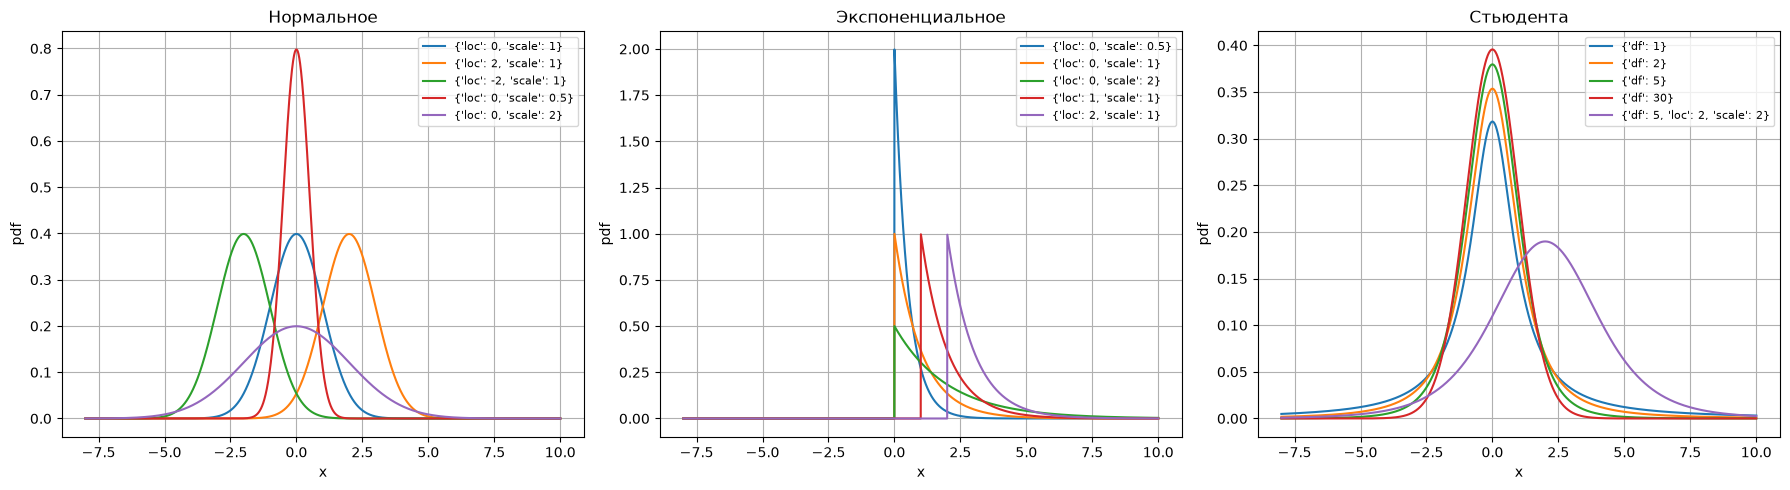

In [3]:
import matplotlib.pyplot as plt
from scipy.stats import norm,expon,t
families = [
    ('Нормальное',norm,[{'loc':0,'scale':1},{'loc':2,'scale':1},{'loc':-2,'scale':1},{'loc':0,'scale':0.5},{'loc':0,'scale':2}]),
    ('Экспоненциальное',expon,[{'loc':0,'scale':0.5},{'loc':0,'scale':1},{'loc':0,'scale':2},{'loc':1,'scale':1},{'loc':2,'scale':1}]),
    ('Стьюдента',t,[{'df':1},{'df':2},{'df':5},{'df':30},{'df':5,'loc':2,'scale':2}])
]
grid = np.linspace(-8,10,3000)
fig, axes = plt.subplots(1,3,figsize=(18,5))
for ax,(title,distribution,parameters) in zip(axes,families):
    for params in parameters:
        ax.plot(grid,distribution.pdf(grid,**params),label=str(params))
    ax.set(title=title,xlabel='x',ylabel='pdf'); ax.legend(fontsize=8); ax.grid()
plt.tight_layout(); plt.show()

## Решение и проверка

Решение подготовлено AI по запросу владельца репозитория. Выполнение подтверждает работоспособность кода; самостоятельное владение материалом не оценивалось.

У каждого события вероятность 1/2. Для каждой пары пересечение равно 1/4. Все три происходят лишь для 000 и 111: вероятность 1/4, тогда как произведение вероятностей равно 1/8.

loc сдвигает распределение, scale растягивает и снижает высоту плотности. У экспоненциального распределения носитель начинается в loc, среднее loc + scale. У Стьюдента меньшие df дают более тяжёлые хвосты; при df > 1 среднее равно loc, при df > 2 дисперсия scale²·df/(df−2). При больших df приближается к нормальному.